In [3]:
import numpy as np
import os

# Define the path to your input folder
data_path = '../input/generate'  # Replace 'your-dataset-folder' with your actual folder name

# Load the combined images and labels
combined_images = np.load(os.path.join(data_path, 'combined_images.npy'))
combined_labels = np.load(os.path.join(data_path, 'combined_labels.npy'))

print(f"Shape of combined images: {combined_images.shape}")
print(f"Shape of combined labels: {combined_labels.shape}")


Shape of combined images: (14818, 128, 128, 1)
Shape of combined labels: (14818,)


Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.98      0.93      1341
   Malignant       0.98      0.89      0.93      1623

    accuracy                           0.93      2964
   macro avg       0.93      0.93      0.93      2964
weighted avg       0.93      0.93      0.93      2964

Confusion Matrix:


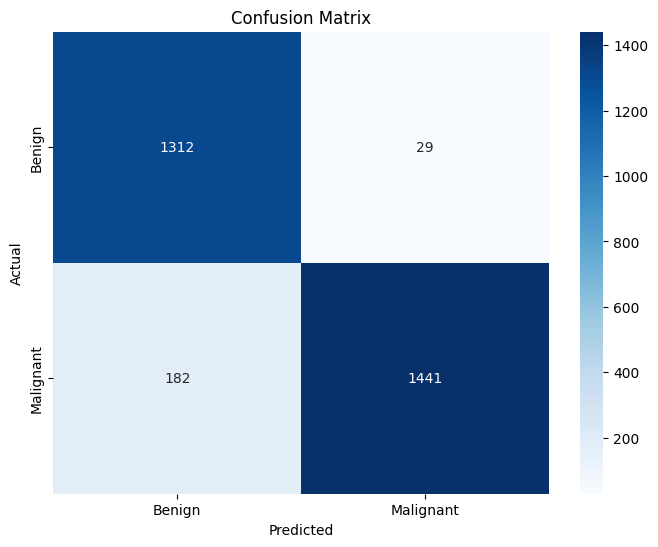

Model Accuracy: 92.88%


In [5]:
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the images to fit the RandomForest input requirements (2D array)
X = combined_images.reshape(combined_images.shape[0], -1)
y = combined_labels

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the RandomForest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
